In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import butter, filtfilt


# Tidsdomene av data

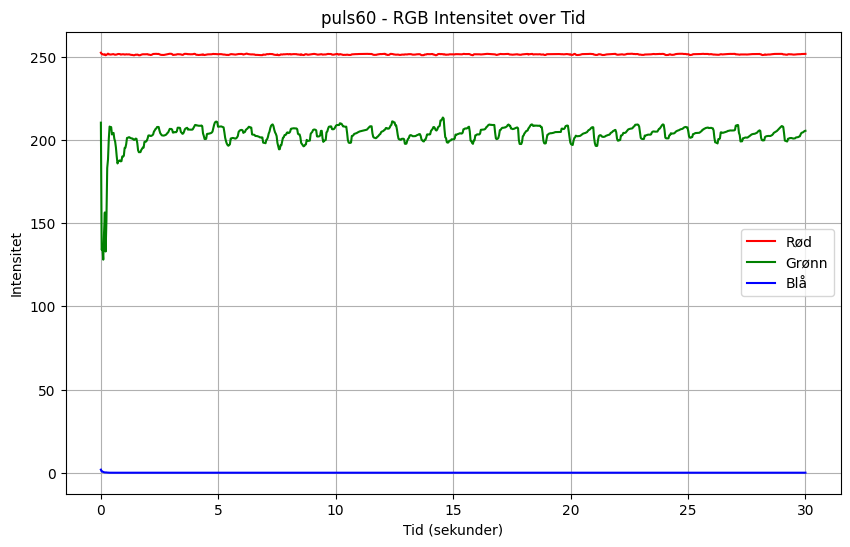

In [11]:
# Importer data fra tekstfilen
navn_fil = 'puls60' 
data = np.loadtxt(f"Txt_målinger/{navn_fil}", delimiter=' ')

# Del opp kolonnene
red = data[:, 0]
green = data[:, 1]
blue = data[:, 2]

lenge = np.linspace(0, 30, len(red))

plt.figure(figsize=(10, 6))
plt.plot(lenge, red, label='Rød', color='red')
plt.plot(lenge, green, label='Grønn', color='green')
plt.plot(lenge, blue, label='Blå', color='blue')
plt.xlabel('Tid (sekunder)')
plt.ylabel('Intensitet')
plt.title(f'{navn_fil} - RGB Intensitet over Tid')
plt.legend()
plt.grid()

#plt.savefig(f'Figurer/RGB "{navn_fil}".png')


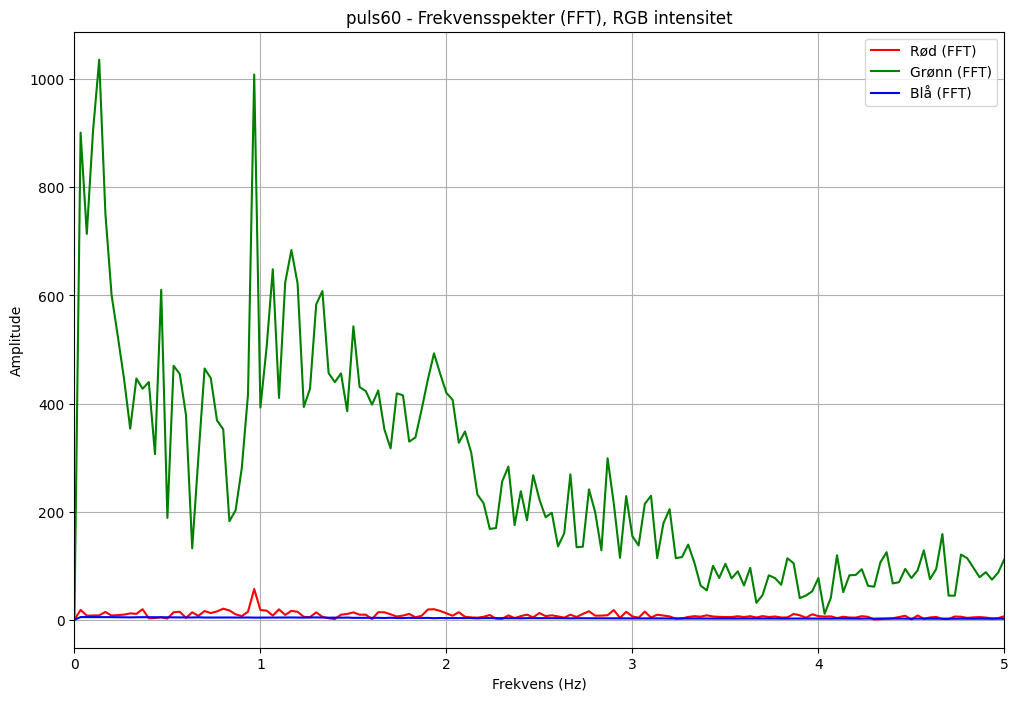

In [12]:

# Beregn FFT for hver kanal
N = len(red)  # Antall prøver
sample_period = 30 / N  # Samplingsperiode (total tid / antall prøver)
freq = np.fft.fftfreq(N, d=sample_period)  # Frekvensaksen


red_mean = np.mean(red)
green_mean = np.mean(green)
blue_mean = np.mean(blue)

  
rød = red - red_mean 
grønn = green - green_mean 
blå = blue - blue_mean

fft_red = np.fft.rfft(rød)
fft_green = np.fft.rfft(grønn)
fft_blue = np.fft.rfft(blå)

# Ta absoluttverdien for å få størrelsen på frekvenskomponentene
magnitude_red = np.abs(fft_red)
magnitude_green = np.abs(fft_green)
magnitude_blue = np.abs(fft_blue)


# Plot frekvensspekteret
plt.figure(figsize=(12, 8))
plt.plot(freq[:N // 2], magnitude_red[:N // 2], label='Rød (FFT)', color='red')
plt.plot(freq[:N // 2], magnitude_green[:N // 2], label='Grønn (FFT)', color='green')
plt.plot(freq[:N // 2], magnitude_blue[:N // 2], label='Blå (FFT)', color='blue')
plt.xlabel('Frekvens (Hz)')
plt.ylabel('Amplitude')
plt.title(f'{navn_fil} - Frekvensspekter (FFT), RGB intensitet')
plt.xlim(0, 5)  # Begrens x-aksen til 0-5 Hz for bedre visning
plt.legend()
plt.grid()
plt.show()

#plt.savefig(f'Figurer/FFT "{navn_fil}" - ufiltrert.png')



# MED FILTER

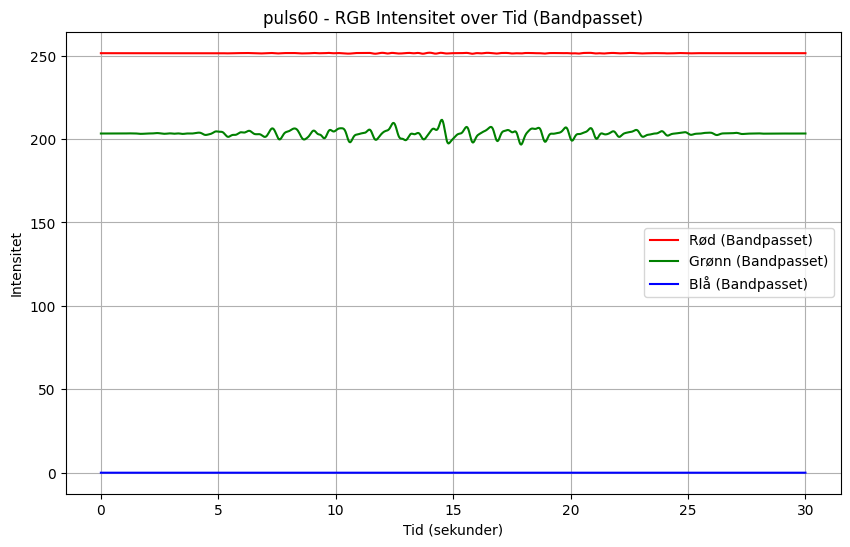

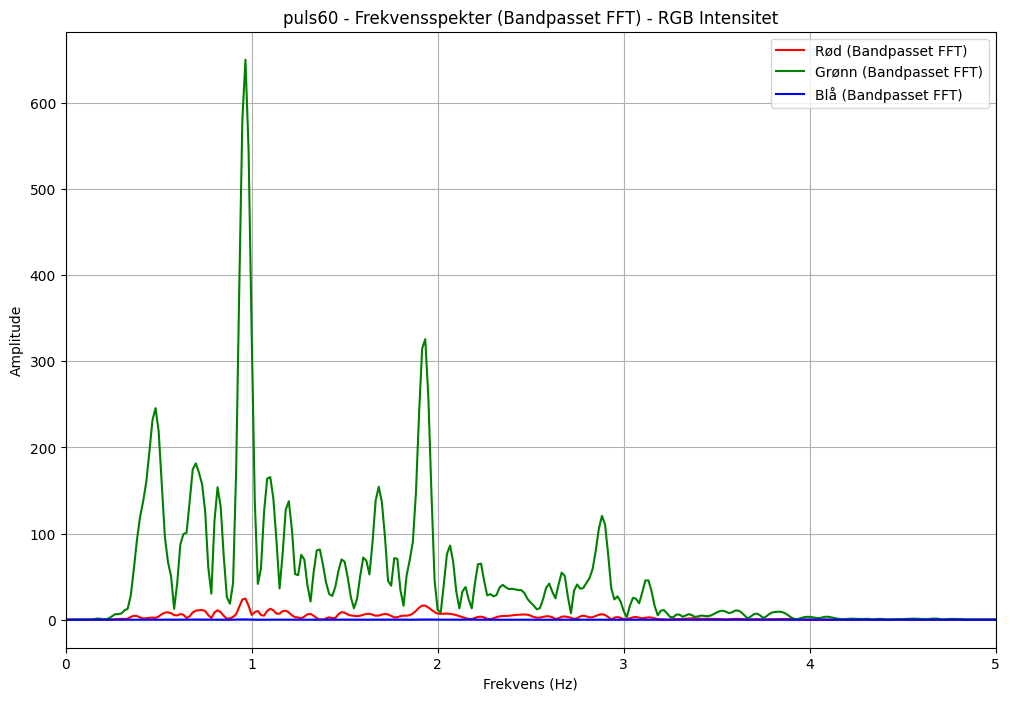

29.7


In [13]:
fs = 40
nedre_grense = 0.5
øvre_grense = 4.0
b, a = butter(3, [nedre_grense/(fs/2) , øvre_grense/(fs/2)], btype='band')  
vindu = np.hanning(N)


# ================ Filtrer og vindu ======================
filtered_red = filtfilt(b, a, rød * vindu)
filtered_green = filtfilt(b, a, grønn * vindu)
filtered_blue = filtfilt(b, a, blå * vindu)

plt.figure(figsize=(10, 6))
plt.plot(lenge, filtered_red + red_mean, label='Rød (Bandpasset)', color='red')
plt.plot(lenge, filtered_green + green_mean, label='Grønn (Bandpasset)', color='green')
plt.plot(lenge, filtered_blue + blue_mean, label='Blå (Bandpasset)', color='blue')
plt.xlabel('Tid (sekunder)')
plt.ylabel('Intensitet')
plt.title(f'{navn_fil} - RGB Intensitet over Tid (Bandpasset)')
plt.legend()
plt.grid()

# ======================= Zero padding =====================
fft_filtered_red = np.fft.rfft(filtered_red, N*2)
fft_filtered_green = np.fft.rfft(filtered_green, N*2)
fft_filtered_blue = np.fft.rfft(filtered_blue, N*2)
freq = np.fft.rfftfreq(N*2, d=sample_period)  

magnitude_filtered_red = np.abs(fft_filtered_red)
magnitude_filtered_green = np.abs(fft_filtered_green)
magnitude_filtered_blue = np.abs(fft_filtered_blue)


plt.figure(figsize=(12, 8))
plt.plot(freq[:N // 2], magnitude_filtered_red[:N // 2], label='Rød (Bandpasset FFT)', color='red')
plt.plot(freq[:N // 2], magnitude_filtered_green[:N // 2], label='Grønn (Bandpasset FFT)', color='green')
plt.plot(freq[:N // 2], magnitude_filtered_blue[:N // 2], label='Blå (Bandpasset FFT)', color='blue')
plt.xlabel('Frekvens (Hz)')
plt.ylabel('Amplitude')
plt.title(f'{navn_fil} - Frekvensspekter (Bandpasset FFT) - RGB Intensitet')
plt.xlim(0, 5)  # Begrens x-aksen til 0-5 Hz for bedre visning
plt.legend()
plt.grid()
plt.show()
print(N/30)


# Finne puls

In [14]:
def finn_pulsfrekvens(magnitude, freq):
    relevant_indices = np.where((freq >= nedre_grense) & (freq <= øvre_grense))
    relevant_magnitude = magnitude[relevant_indices]
    relevant_freq = freq[relevant_indices]

    if len(relevant_magnitude) == 0:
        return None  # Ingen relevante frekvenser funnet

    max_index = np.argmax(relevant_magnitude)
    pulsfrekvens = relevant_freq[max_index]
    
    return pulsfrekvens


pulsfrekvens_red_før = finn_pulsfrekvens(magnitude_red, freq)
pulsfrekvens_green_før = finn_pulsfrekvens(magnitude_green, freq)
pulsfrekvens_blue_før = finn_pulsfrekvens(magnitude_blue, freq)
print(f"Pulsfrekvens før (Rød): {pulsfrekvens_red_før * 60:.2f} BPM")
print(f"Pulsfrekvens før (Grønn): {pulsfrekvens_green_før * 60:.2f} BPM")
print(f"Pulsfrekvens før (Blå): {pulsfrekvens_blue_før * 60:.2f} BPM")



pulsfrekvens_red = finn_pulsfrekvens(magnitude_filtered_red, freq)
pulsfrekvens_green = finn_pulsfrekvens(magnitude_filtered_green, freq)
pulsfrekvens_blue = finn_pulsfrekvens(magnitude_filtered_blue, freq)
print(f"Pulsfrekvens (Rød): {pulsfrekvens_red * 60:.2f} BPM")
print(f"Pulsfrekvens (Grønn): {pulsfrekvens_green * 60:.2f} BPM")
print(f"Pulsfrekvens (Blå): {pulsfrekvens_blue * 60:.2f} BPM")



Pulsfrekvens før (Rød): 58.00 BPM
Pulsfrekvens før (Grønn): 35.00 BPM
Pulsfrekvens før (Blå): 34.00 BPM
Pulsfrekvens (Rød): 58.00 BPM
Pulsfrekvens (Grønn): 58.00 BPM
Pulsfrekvens (Blå): 57.00 BPM


# SNR

In [15]:

Puls_på_klokke = 60  
Pulse_frekvens = Puls_på_klokke / 60  # Eksempel: 60 BPM tilsvarer 1 Hz
Målt_pulsfrekvens = pulsfrekvens_green  

frequency_tolerance = 0.1  # I Hz

# Finn indeksene til frekvensene innenfor intervallet [pulse_frequency - 0.5, pulse_frequency + 0.5]
signal_indices = np.where((freq >= Målt_pulsfrekvens - frequency_tolerance) & 
                          (freq <= Målt_pulsfrekvens + frequency_tolerance))[0]


effekt_rød_før = (magnitude_red[:N // 2]**2) / N**2
effekt_grønn_før = (magnitude_green[:N // 2]**2) / N**2
effekt_blå_før = (magnitude_blue[:N // 2]**2) / N**2

effekt_rød_etter = (magnitude_filtered_red[:N // 2]**2) / N**2
effekt_grønn_etter = (magnitude_filtered_green[:N // 2]**2) / N**2
effekt_blå_etter = (magnitude_filtered_blue[:N // 2]**2) / N**2


# ================== Før filtrering ==================

# Signalstyrke før filtrering SUMMER ALT INNENFOR ET OMRÅDET
signal_power_red_before = np.sum(effekt_rød_før[signal_indices])
signal_power_green_before = np.sum(effekt_grønn_før[signal_indices])
signal_power_blue_before = np.sum(effekt_blå_før[signal_indices])


# Støystyrke før filtrering GJENNOMSNITT
noise_power_red_before = np.mean(np.delete(effekt_rød_før, signal_indices))
noise_power_green_before = np.mean(np.delete(effekt_grønn_før, signal_indices))
noise_power_blue_before = np.mean(np.delete(effekt_blå_før, signal_indices))
#print(noise_power_green_before)

# Beregn SNR før filtrering
SNR_red_before = 10 * np.log10(signal_power_red_before / noise_power_red_before)
SNR_green_before = 10 * np.log10(signal_power_green_before / noise_power_green_before)
SNR_blue_before = 10 * np.log10(signal_power_blue_before / noise_power_blue_before)




# ==================== Etter filtrering =================
# Signalstyrke etter filtrering (maksimal verdi innenfor intervallet)
signal_power_red_after = np.sum(magnitude_filtered_red[signal_indices])
signal_power_green_after = np.sum(magnitude_filtered_green[signal_indices])
signal_power_blue_after = np.sum(magnitude_filtered_blue[signal_indices])
#print(signal_power_green_after)
# Støystyrke etter filtrering (summen av alle andre frekvenser utenfor signalområdet)
noise_power_red_after = np.mean(np.delete(magnitude_filtered_red, signal_indices))
noise_power_green_after = np.mean(np.delete(magnitude_filtered_green, signal_indices))
noise_power_blue_after = np.mean(np.delete(magnitude_filtered_blue, signal_indices))

#print(noise_power_green_after)
# Beregn SNR etter filtrering
SNR_red_after = 10 * np.log10(signal_power_red_after / noise_power_red_after)
SNR_green_after = 10 * np.log10(signal_power_green_after / noise_power_green_after)
SNR_blue_after = 10 * np.log10(signal_power_blue_after / noise_power_blue_after)







# Print resultatene
print("SNR før filtrering:")
print(f"Rød: {SNR_red_before:.2f} dB")
print(f"Grønn: {SNR_green_before:.2f} dB")
print(f"Blå: {SNR_blue_before:.2f} dB")

print("\nSNR etter filtrering:")
print(f"Rød: {SNR_red_after:.2f} dB")
print(f"Grønn: {SNR_green_after:.2f} dB")
print(f"Blå: {SNR_blue_after:.2f} dB")

SNR før filtrering:
Rød: 16.78 dB
Grønn: 17.20 dB
Blå: 14.42 dB

SNR etter filtrering:
Rød: 21.32 dB
Grønn: 23.69 dB
Blå: 20.97 dB


#### Sivert sin

In [16]:
def compute_snr(signal, fs):

    N = len(signal)

    freqs = np.fft.rfftfreq(N, 1/fs)
    fft_vals = np.abs(np.fft.rfft(signal)) / N

    
    mask = (freqs >= 0.5) & (freqs <= 4)

    freqs_band = freqs[mask]
    fft_band = fft_vals[mask]

    
    peak_idx = np.argmax(fft_band)
    peak_freq = freqs_band[peak_idx]
    peak_amp = fft_band[peak_idx]

    
    exclude = 0.1
    noise_mask = np.abs(freqs_band - peak_freq) > exclude
    noise_vals = fft_band[noise_mask]

    noise_mean = np.mean(noise_vals)

    snr_linear = peak_amp / noise_mean
    snr_db = 20 * np.log10(snr_linear)

    bpm = peak_freq * 60

    return bpm, snr_linear, snr_db

bpm_R, snr_R, snr_R_db = compute_snr(filtered_red, fs)
bpm_G, snr_G, snr_G_db = compute_snr(filtered_green, fs)
bpm_B, snr_B, snr_B_db = compute_snr(filtered_blue, fs)

print("R: BPM =", f"{bpm_R:.1f}", "SNR =", f"{snr_R_db:.1f}", "dB")
print("G: BPM =", f"{bpm_G:.1f}", "SNR =", f"{snr_G_db:.1f}", "dB")
print("B: BPM =", f"{bpm_B:.1f}", "SNR =", f"{snr_B_db:.1f}", "dB")

R: BPM = 78.1 SNR = 13.6 dB
G: BPM = 78.1 SNR = 18.6 dB
B: BPM = 78.1 SNR = 11.3 dB


# SISTE FIGURER

### UFILTRERT

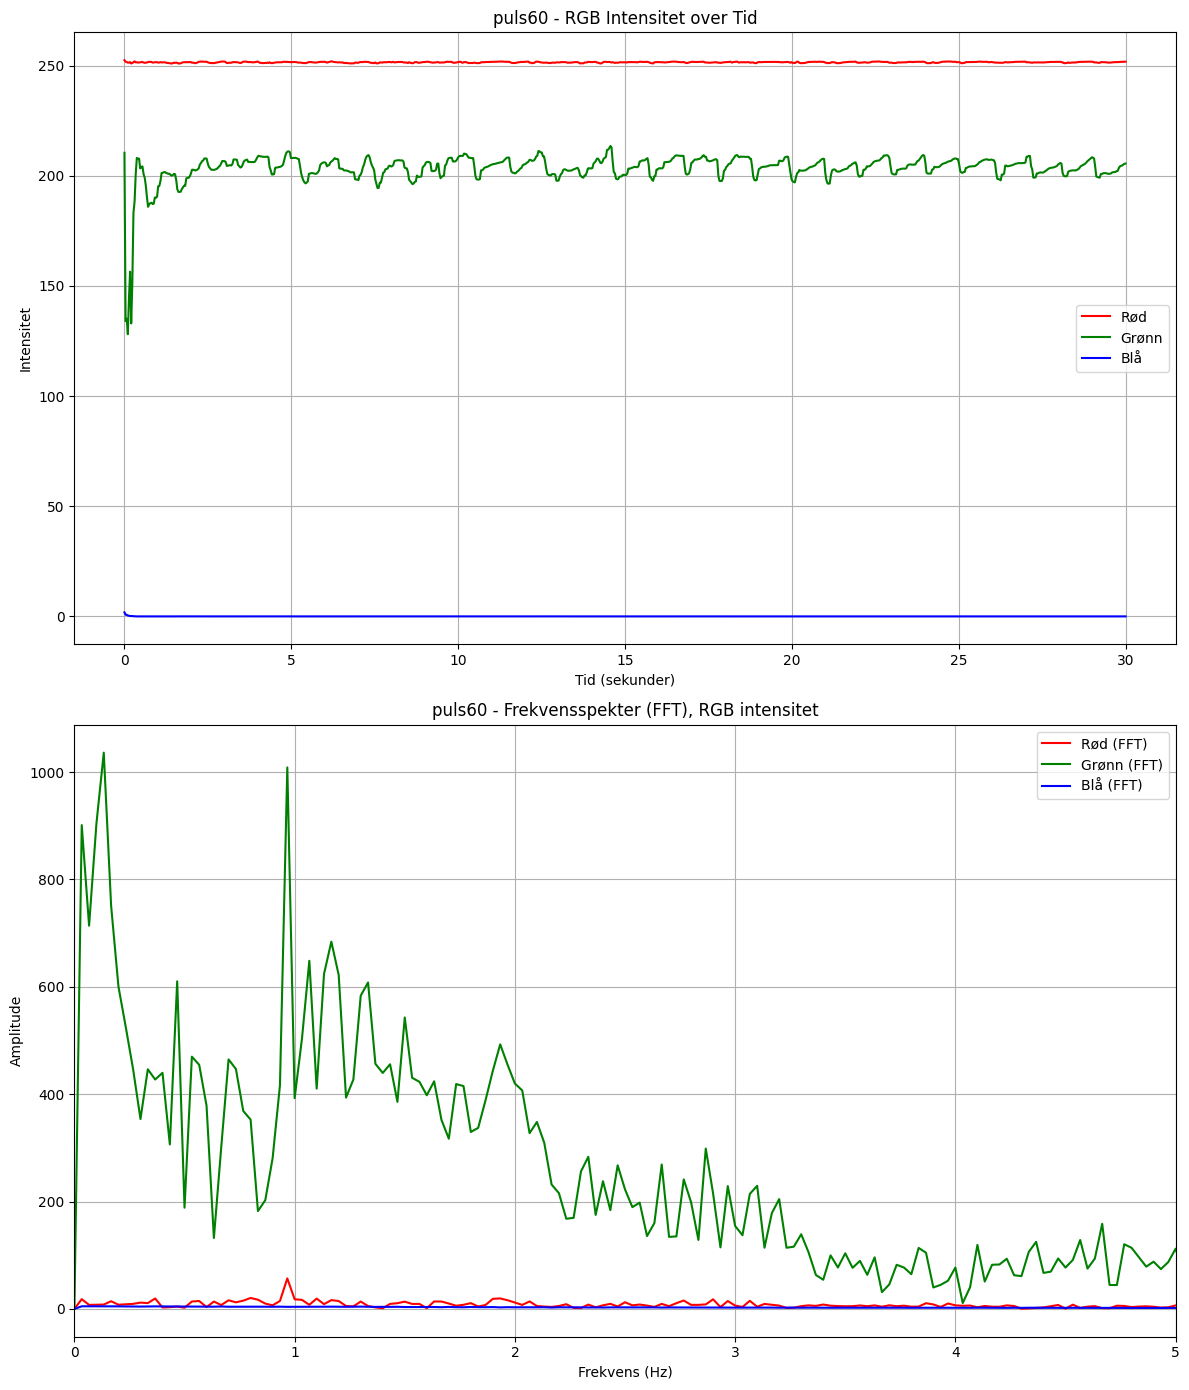

In [17]:
fig, axs = plt.subplots(2, 1, figsize=(12, 14))  # Opprett et lerret med 2 rader og 1 kolonne

# Første subplot: RGB Intensitet over Tid
axs[0].plot(lenge, red, label='Rød', color='red')
axs[0].plot(lenge, green, label='Grønn', color='green')
axs[0].plot(lenge, blue, label='Blå', color='blue')
axs[0].set_xlabel('Tid (sekunder)')
axs[0].set_ylabel('Intensitet')
axs[0].set_title(f'{navn_fil} - RGB Intensitet over Tid')
axs[0].legend()
axs[0].grid()
freq = np.fft.fftfreq(N, d=sample_period)  # Frekvensaksen
# Andre subplot: Frekvensspekter
axs[1].plot(freq[:N // 2], magnitude_red[:N // 2], label='Rød (FFT)', color='red')
axs[1].plot(freq[:N // 2], magnitude_green[:N // 2], label='Grønn (FFT)', color='green')
axs[1].plot(freq[:N // 2], magnitude_blue[:N // 2], label='Blå (FFT)', color='blue')
axs[1].set_xlabel('Frekvens (Hz)')
axs[1].set_ylabel('Amplitude')
axs[1].set_title(f'{navn_fil} - Frekvensspekter (FFT), RGB intensitet')
axs[1].set_xlim(0, 5)  # Begrens x-aksen til 0-5 Hz for bedre visning
axs[1].legend()
axs[1].grid()

# Juster layout og lagre figuren
plt.tight_layout()
plt.savefig(f'Figurer/FFT og RGB {navn_fil} ufiltrert.png')
plt.show()

### FILTRERT

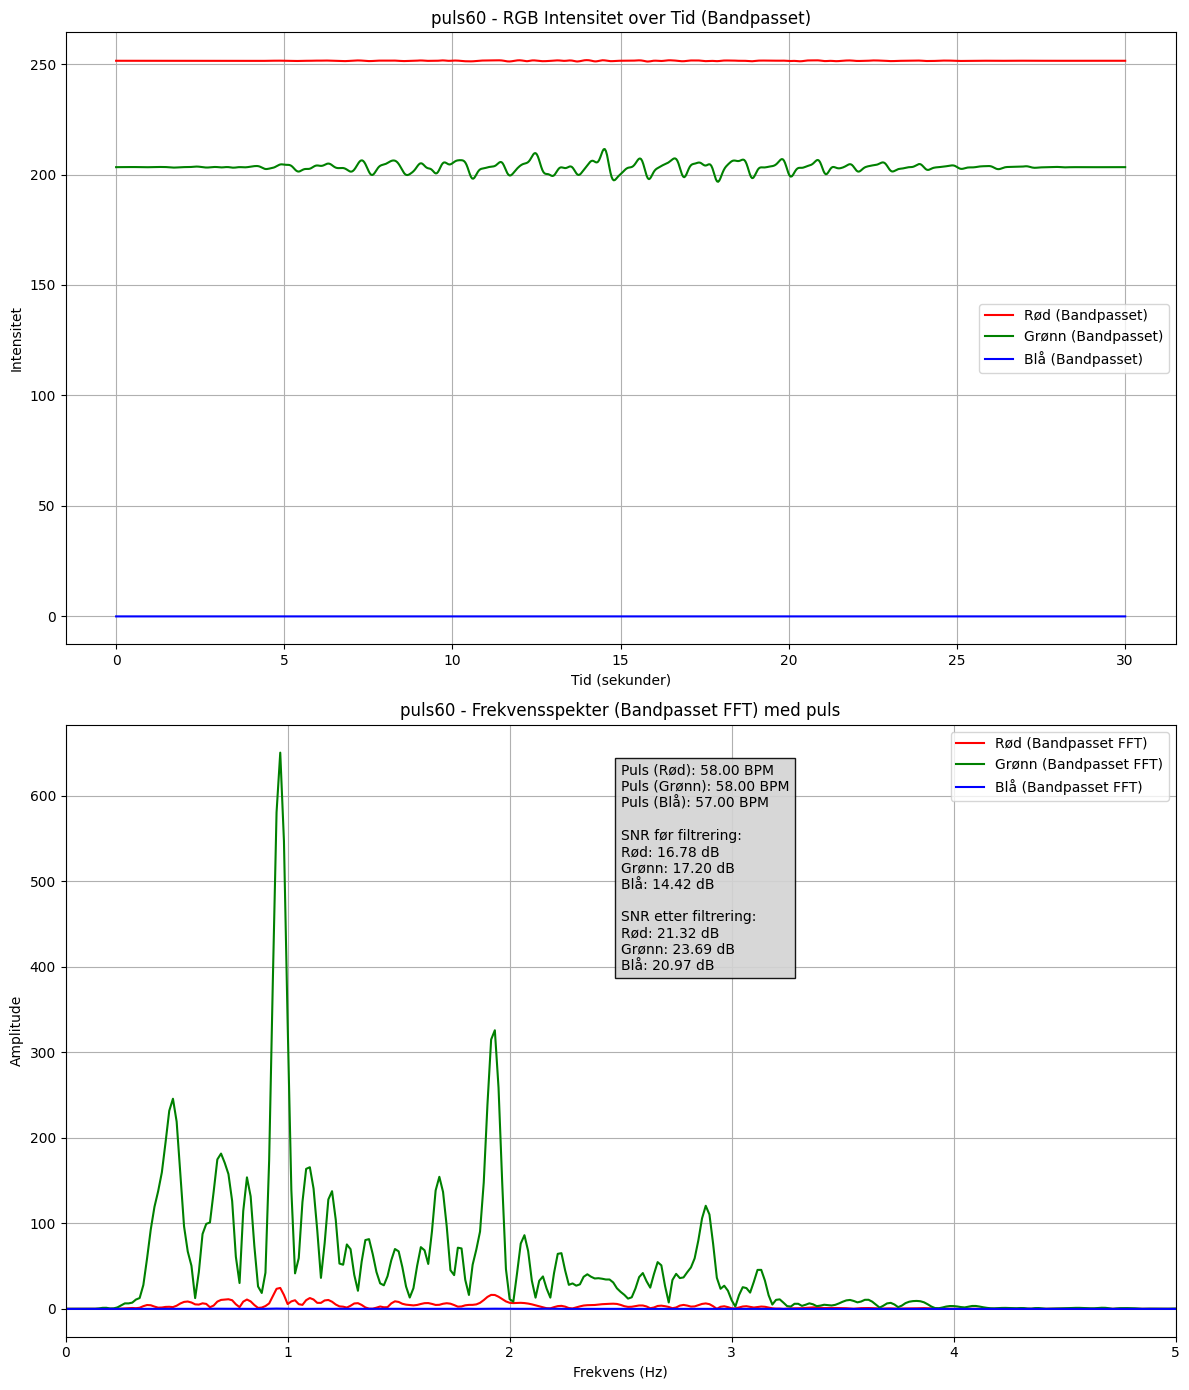

In [18]:
fig, axs = plt.subplots(2, 1, figsize=(12, 14))  # Opprett et lerret med 2 rader og 1 kolonne

# Første subplot: RGB Intensitet over Tid
axs[0].plot(lenge, filtered_red + red_mean, label='Rød (Bandpasset)', color='red')
axs[0].plot(lenge, filtered_green + green_mean, label='Grønn (Bandpasset)', color='green')
axs[0].plot(lenge, filtered_blue + blue_mean, label='Blå (Bandpasset)', color='blue')
axs[0].set_xlabel('Tid (sekunder)')
axs[0].set_ylabel('Intensitet')
axs[0].set_title(f'{navn_fil} - RGB Intensitet over Tid (Bandpasset)')
axs[0].legend()
axs[0].grid()

freq = np.fft.rfftfreq(N*2, d=sample_period)  # Oppdatert frekvensakse for den nye FFT-størrelsen

# Andre subplot: Frekvensspekter
axs[1].plot(freq[:N // 2], magnitude_filtered_red[:N // 2], label='Rød (Bandpasset FFT)', color='red')
axs[1].plot(freq[:N // 2], magnitude_filtered_green[:N // 2], label='Grønn (Bandpasset FFT)', color='green')
axs[1].plot(freq[:N // 2], magnitude_filtered_blue[:N // 2], label='Blå (Bandpasset FFT)', color='blue')
axs[1].set_xlabel('Frekvens (Hz)')
axs[1].set_ylabel('Amplitude')
axs[1].set_title(f'{navn_fil} - Frekvensspekter (Bandpasset FFT) med puls')

pulse_text = (
    f"Puls (Rød): {pulsfrekvens_red * 60:.2f} BPM\n"
    f"Puls (Grønn): {pulsfrekvens_green * 60:.2f} BPM\n"
    f"Puls (Blå): {pulsfrekvens_blue * 60:.2f} BPM\n\n"
    f"SNR før filtrering:\n"
    f"Rød: {SNR_red_before:.2f} dB\n"
    f"Grønn: {SNR_green_before:.2f} dB\n"
    f"Blå: {SNR_blue_before:.2f} dB\n\n"
    f"SNR etter filtrering:\n"
    f"Rød: {SNR_red_after:.2f} dB\n"
    f"Grønn: {SNR_green_after:.2f} dB\n"
    f"Blå: {SNR_blue_after:.2f} dB"
)
axs[1].text(0.5, 0.6, pulse_text, fontsize=10, bbox=dict(facecolor='lightgrey', alpha=0.9), transform=axs[1].transAxes)
axs[1].set_xlim(0, 5)
axs[1].legend()
axs[1].grid()

# Juster layout og lagre figuren
plt.tight_layout()
plt.savefig(f'Figurer/FFT, Puls og RGB {navn_fil} Filtrert.png')
plt.show()